# Machine Learning Introduction

Machine Learning (ML) is a subset of artificial intelligence that enables computers to learn from data and improve their performance without being explicitly programmed. Instead of following rigid, hand-coded rules, ML algorithms identify patterns in data and make predictions or decisions based on those patterns.

## Why Machine Learning?

- **Automation**: ML can automate complex tasks that would be impractical to code manually
- **Pattern Recognition**: Excellent at finding patterns in large, complex datasets
- **Adaptability**: Models can improve over time as they receive more data
- **Applications**: Powers everything from recommendation systems to image recognition

## Types of Machine Learning

| Type | Description | Examples |
|------|-------------|----------|
| **Supervised Learning** | Learns from labeled data | Classification, Regression |
| **Unsupervised Learning** | Finds patterns in unlabeled data | Clustering, Dimensionality Reduction |
| **Reinforcement Learning** | Learns through trial and error | Game AI, Robotics |

## What We'll Cover

In this notebook, we'll explore fundamental ML concepts and techniques. You'll learn how to:
1. Preprocess and prepare data for training
2. Build and train different types of models
3. Evaluate model performance
4. Optimize and improve your predictions

Let's get started!

## Step 1: Setup - Import Libraries

First, we need to import the essential libraries. These are the building blocks for any ML project:

- **NumPy**: Numerical Python - handles efficient numerical computations
- **Matplotlib**: Visualization library - plots charts and graphs
- **pandas**: Data manipulation - works with tables/data frames
- **scikit-learn**: Machine Learning toolkit - provides ML algorithms

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Creating Sample Data

ML models learn from data. For beginners, we'll create simple synthetic data so we can focus on learning the concepts. Here we create two datasets:

- **X and y**: Simple 1D data for regression (predicting a continuous value)
- **X_class and y_class**: Data for classification (predicting categories)

In [7]:
np.random.seed(42)

# Simple data for regression: relationship between study hours and score
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([20, 35, 48, 62, 75, 85, 92, 96, 98, 99])

# Simple data for classification: pass/fail based on study hours
X_class = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y_class = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])  # 0=fail, 1=pass

print("Regression data (X, y):", X.flatten(), "->", y)
print("Classification data (X_class, y_class):", X_class.flatten(), "->", y_class)

Regression data (X, y): [ 1  2  3  4  5  6  7  8  9 10] -> [20 35 48 62 75 85 92 96 98 99]
Classification data (X_class, y_class): [ 1  2  3  4  5  6  7  8  9 10] -> [0 0 0 0 1 1 1 1 1 1]


## Step 3: Train/Test Split

To evaluate our model fairly, we split data into two sets:

- **Training set**: Used to teach the model (80% of data)
- **Test set**: Used to check how well the model learned (20% of data)

This helps detect if our model is overfitting (memorizing) or generalizing (learning)!
test_size=0.2 means 20% goes to test, random_state=42 makes results reproducible.

In [8]:
# Split regression data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split classification data
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 8
Test samples: 2


## Step 4: Supervised Learning - Linear Regression

**Regression** predicts continuous values (like prices, temperatures, scores).

**Linear Regression** finds the best straight line that fits your data:
- y = mx + b (where m is slope, b is intercept)
- The algorithm learns the best m and b values from training data

Example: Predicting exam score based on study hours

In [9]:
# Create the model
model = LinearRegression()

# Train the model on training data
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Show results
print(f"Learned slope (m): {model.coef_[0]:.2f}")
print(f"Learned intercept (b): {model.intercept_:.2f}")
print(f"\nActual test values: {y_test}")
print(f"Predicted values: {y_pred.astype(int)}")

Learned slope (m): 9.06
Learned intercept (b): 22.29

Actual test values: [98 35]
Predicted values: [103  40]


## Step 5: Supervised Learning - Logistic Regression

**Classification** predicts categories (like spam/not spam, pass/fail).

**Logistic Regression** outputs probabilities between 0 and 1:
- If probability > 0.5, predict class 1
- If probability < 0.5, predict class 0

Example: Predicting if a student will pass based on study hours

In [10]:
# Create the classification model
class_model = LogisticRegression()

# Train the model
class_model.fit(X_class_train, y_class_train)

# Make predictions
y_class_pred = class_model.predict(X_class_test)

# Calculate accuracy
accuracy = accuracy_score(y_class_test, y_class_pred)

print(f"Test values: {y_class_test}")
print(f"Predictions: {y_class_pred}")
print(f"Accuracy: {accuracy * 100:.0f}%")

Test values: [1 0]
Predictions: [1 0]
Accuracy: 100%


## Step 6: Unsupervised Learning - K-Means Clustering

**Clustering** finds natural groups in data without predefined labels.

**K-Means** groups data into K clusters:
- Randomly place K centroids (center points)
- Assign each data point to nearest centroid
- Move centroids to center of their cluster
- Repeat until convergence

Example: Grouping students by their scores (no predefined categories)

In [11]:
# Create 2D data for clustering (study hours vs score)
X_cluster = np.array([[1, 20], [2, 35], [3, 45], [8, 85], [9, 90], [10, 95]])

# Create K-Means model with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the model
kmeans.fit(X_cluster)

# Get cluster labels
labels = kmeans.labels_

print("Data points:", X_cluster.tolist())
print("Assigned clusters:", labels.tolist())
print("Cluster centers:", kmeans.cluster_centers_.tolist())

Data points: [[1, 20], [2, 35], [3, 45], [8, 85], [9, 90], [10, 95]]
Assigned clusters: [0, 0, 0, 1, 1, 1]
Cluster centers: [[2.0, 33.33333333333333], [9.0, 90.0]]


## Step 7: Model Evaluation Metrics

How do we know if our model is good? We use metrics:

**For Regression:**
- **R² Score**: How well the model explains the data (1.0 = perfect, 0.0 = terrible)
- **MSE (Mean Squared Error)**: Average squared difference between predicted and actual

**For Classification:**
- **Accuracy**: Percentage of correct predictions

Let's evaluate our regression model with these metrics!

In [12]:
# Evaluate regression model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("=== Regression Model Evaluation ===")
print(f"R² Score: {r2:.3f} (1.0 = perfect)")
print(f"MSE: {mse:.2f} (lower is better)")

if r2 > 0.9:
    print("Great model!")
elif r2 > 0.7:
    print("Good model!")
else:
    print("Model needs improvement.")

=== Regression Model Evaluation ===
R² Score: 0.968 (1.0 = perfect)
MSE: 31.69 (lower is better)
Great model!


## Step 8: Visualizing Results

Visualization helps us understand our model intuitively:

- **Scatter plot**: Shows actual data points
- **Line**: Shows the model's predictions

This chart shows our linear regression model fitting the study hours vs score data.

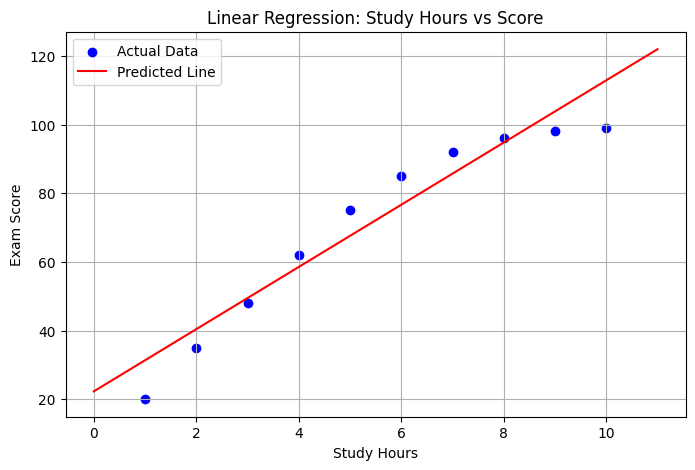

In [13]:
# Create simple visualization
plt.figure(figsize=(8, 5))

# Plot actual data points
plt.scatter(X, y, color='blue', label='Actual Data')

# Plot regression line (predicted values)
X_line = np.linspace(0, 11, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', label='Predicted Line')

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Study Hours vs Score')
plt.legend()
plt.grid(True)
plt.show()

## Summary

You've learned the core machine learning concepts:

### What We Covered:
1. **Setup**: Importing essential libraries (NumPy, Matplotlib, pandas, scikit-learn)
2. **Data Creation**: Creating sample data for learning
3. **Train/Test Split**: Splitting data for training and evaluation (80/20)
4. **Linear Regression**: Predicting continuous values (regression)
5. **Logistic Regression**: Predicting categories (classification)
6. **K-Means Clustering**: Finding groups without labels (unsupervised)
7. **Evaluation**: Using R², MSE, and accuracy metrics
8. **Visualization**: Charting results for understanding

### Key Takeaways:
- **Supervised Learning**: Uses labeled data to learn (regression & classification)
- **Unsupervised Learning**: Finds patterns without labels (clustering)
- **Always split data**: Train on some data, test on separate data
- **Evaluate metrics**: Use R², MSE, accuracy to measure performance

### Next Steps:
- Try real datasets (Kaggle has many beginner-friendly ones)
- Explore more algorithms (Decision Trees, Random Forests)
- Learn about data preprocessing (handling missing values, scaling)

Happy Learning!

In [14]:
# Congratulations! You've completed the ML introduction notebook.
print("🎉 Congratulations! You've completed the ML Introduction notebook!")
print("\nWhat you learned:")
print("- Setup and import libraries")
print("- Create and split data")
print("- Linear Regression (predicting numbers)")
print("- Logistic Regression (predicting categories)")
print("- K-Means Clustering (finding groups)")
print("- Model evaluation metrics")
print("- Data visualization")

🎉 Congratulations! You've completed the ML Introduction notebook!

What you learned:
- Setup and import libraries
- Create and split data
- Linear Regression (predicting numbers)
- Logistic Regression (predicting categories)
- K-Means Clustering (finding groups)
- Model evaluation metrics
- Data visualization
